# **K-Means Clustering (Mall Customers Dataset)**

### **Import Libraries**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### **Load Dataset**

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### **Basic Info**

In [5]:
print("Info: ")
print("-"*100)
print(df.info())

print("\n" + "="*100 + "\n")

print("Description: ")
print("-"*100)
print(df.describe())

Info: 
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


Description: 
----------------------------------------------------------------------------------------------------
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721   

In [6]:
df.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### **EDA – Scatter Plot(Annual Income vs Spending Score)**

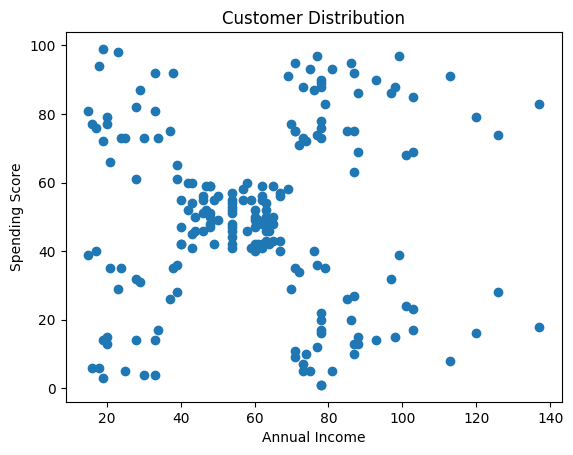

In [7]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

### **EDA – Scatter Plot(Age vs Spending Score)**

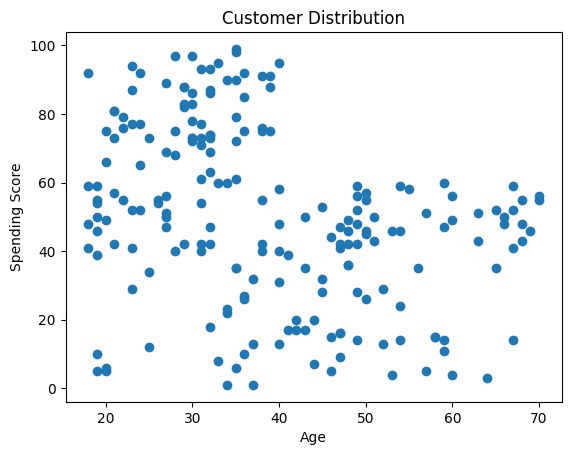

In [8]:
plt.scatter(df["Age"], df['Spending Score (1-100)'])

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

## **Model-1**

### **Select Features**

In [9]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

### **Feature Scaling**

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Find Optimal Clusters (Elbow Method)**

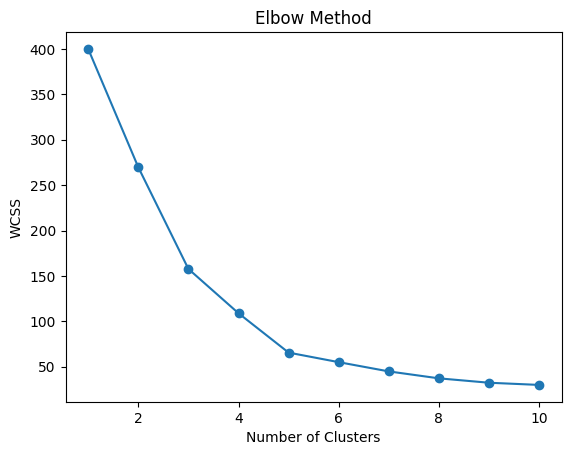

In [11]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### **Train K-Means Model**

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

### **Add Cluster Labels**

In [13]:
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### **Evaluate Model**

In [14]:
score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


### **Visualize Clusters**

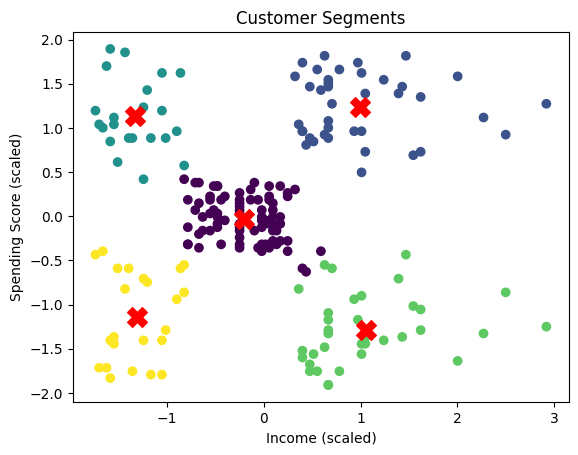

In [15]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X'
        )

plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segments")
plt.show()

---

## **Model-2**

In [16]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


### **Feature Engineering**

In [17]:
df.rename(columns={"Genre": "Gender"}, inplace=True)

data = df.copy()

# age_bins = [18, 30, 50, 75]
# age_groups = ["Adult", "Middle", "Senior"]
# pd.cut(x=df["Age"], bins=age_bins, labels=age_groups, include_lowest=True)

data["Gender"] = data["Gender"].map({
    "Male": 0,
    "Female": 1
})

data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,4
1,2,0,21,15,81,2
2,3,1,20,16,6,4
3,4,1,23,16,77,2
4,5,1,31,17,40,4
...,...,...,...,...,...,...
195,196,1,35,120,79,1
196,197,1,45,126,28,3
197,198,0,32,126,74,1
198,199,0,32,137,18,3


### **Extract Features**

In [18]:
X2 = data[["Gender", "Age", "Annual Income (k$)"]]

### **Scalling**

In [19]:
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

### **Train Model Again**

In [20]:
kmeans2 = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans2 = kmeans2.fit_predict(X2_scaled)

### **Add Cluster**

In [21]:
data["Cluster-2"] = y_kmeans2
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster-2
0,1,0,19,15,39,4,2
1,2,0,21,15,81,2,2
2,3,1,20,16,6,4,2
3,4,1,23,16,77,2,2
4,5,1,31,17,40,4,2
...,...,...,...,...,...,...,...
195,196,1,35,120,79,1,1
196,197,1,45,126,28,3,1
197,198,0,32,126,74,1,3
198,199,0,32,137,18,3,3


### **Evaluate Model**

In [22]:
score2 = silhouette_score(X2_scaled, y_kmeans2)
print("Enhanced Model Silhouette Score:", score2)

Enhanced Model Silhouette Score: 0.3978066655257731


### **Visualization**

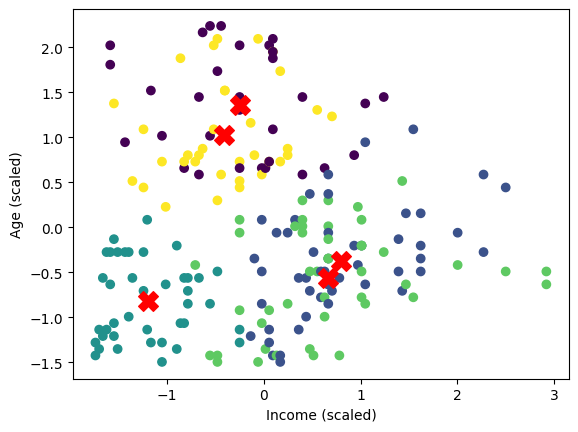

In [23]:
plt.scatter(X2_scaled[:, 2], X2_scaled[:, 1], c=y_kmeans2, cmap='viridis')

plt.scatter(kmeans2.cluster_centers_[:, 2],
            kmeans2.cluster_centers_[:, 1],
            s=200, c='red', marker='X')

plt.xlabel("Income (scaled)")
plt.ylabel("Age (scaled)")
plt.show()

### **Compare**

In [24]:
print("Model-1 score:", score)
print("Model-2: score", score2)

Model-1 score: 0.5546571631111091
Model-2: score 0.3978066655257731


**Observation**

Hence clearly model-1 performs better than model-2 with higher silhouette score and the scatter plot also much les overlap for model-1 compared to kodel-2.